# 📘 SISTEM BERBASIS PENGETAHUAN — BAB 4

## 🔍 Forward Chaining dan Backward Chaining  
### Studi Kasus: Rekomendasi Tempat Wisata Bali

---

## 👤 Identitas Kelompok

| No | Nama | NIM | Kelas |
|----|------|------|-------|
| 1 |  | |  |
| 2 | DINI ELMININGTYAS RAHAYU WILUJENG | 2341760180 | D4 Sistem Informasi Bisnis |
| 3 | IMEL THERESIA BR SEMBIRING  | 2341760046  |D4 Sistem Informasi Bisnis  |
| 4 |  |  |  |
| 5 | MUHAMMAD ULIL FAHMI MA'RIFATULLOH | 2341760194 | D4 Sistem Informasi Bisnis |


---

## 📂 Dataset

- **Nama File**: `dataset_tempat_wisata_bali.xlsx`
- **Deskripsi**: Dataset ini digunakan untuk membangun sistem rekomendasi tempat wisata di Bali menggunakan metode:
  - Forward Chaining
  - Backward Chaining

---

## 🎯 Tujuan

Membangun sistem berbasis pengetahuan yang mampu memberikan rekomendasi tempat wisata di Bali berdasarkan preferensi pengguna menggunakan pendekatan:
- **Forward Chaining** (data-driven)
- **Backward Chaining** (goal-driven)

---

## ⚙️ Metode yang Digunakan

### 1. Forward Chaining
- Memulai dari fakta yang diketahui
- Menelusuri aturan hingga mencapai kesimpulan

### 2. Backward Chaining
- Memulai dari tujuan (goal)
- Menelusuri apakah fakta mendukung tujuan tersebut

---

## 📝 Catatan

- Pastikan dataset sudah di-upload ke environment Colab sebelum dijalankan
- Gunakan library seperti `pandas` untuk pengolahan data

---

# INSTALASI LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from collections import deque
import warnings
warnings.filterwarnings('ignore')

#  BAGIAN 1: LOAD DATA MENTAH

In [ ]:
DATASET_PATH = "dataset_tempat_wisata_bali.xlsx"

print("=" * 65)
print("   SISTEM REKOMENDASI WISATA BALI — KNOWLEDGE-BASED SYSTEM")
print("   Forward Chaining & Backward Chaining")
print("=" * 65)

# Baca semua kolom sebagai string agar tidak ada konversi otomatis
df_raw = pd.read_excel(DATASET_PATH, dtype=str)

print(f"\n[LOAD] Data berhasil dimuat: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom")
print(f"Kolom: {df_raw.columns.tolist()}")

   SISTEM REKOMENDASI WISATA BALI — KNOWLEDGE-BASED SYSTEM
   Forward Chaining & Backward Chaining

[LOAD] Data berhasil dimuat: 761 baris, 8 kolom
Kolom: ['nama', 'kategori', 'kabupaten_kota', 'rating', 'preferensi', 'link', 'latitude', 'longitude']


# BAGIAN 2: PREPROCESSING DATA

In [ ]:
print("\n\n" + "=" * 65)
print("   BAGIAN 2 — PREPROCESSING DATA")
print("=" * 65)

def preprocessing_pipeline(df):
    """
    Pipeline preprocessing lengkap untuk dataset wisata Bali.
    Terdiri dari 9 tahap pemeriksaan dan pembersihan data.
    Mengembalikan (dataframe_bersih, laporan_dict).
    """
    df = df.copy()
    report = {}
    n_awal = len(df)
    report['n_awal'] = n_awal

    # ----------------------------------------------------------
    # TAHAP 1: Inspeksi Awal
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 1 — INSPEKSI AWAL")
    print("─" * 65)

    print(f"  Jumlah baris    : {n_awal}")
    print(f"  Jumlah kolom    : {df.shape[1]}")
    print(f"\n  Tipe data tiap kolom (sebelum konversi):")
    for col in df.columns:
        print(f"    {col:20s}: {df[col].dtype}")

    print(f"\n  Contoh 3 baris pertama:")
    print(tabulate(
        df[['nama','kategori','kabupaten_kota','rating','preferensi',
            'latitude','longitude']].head(3),
        headers='keys', tablefmt='grid', showindex=True
    ))

    # ----------------------------------------------------------
    # TAHAP 2: Pembersihan Whitespace & Standarisasi Teks
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 2 — PEMBERSIHAN WHITESPACE & STANDARISASI TEKS")
    print("─" * 65)

    text_cols = ['nama', 'kategori', 'kabupaten_kota', 'preferensi']
    ws_fixed = 0
    for col in text_cols:
        sebelum = df[col].copy()
        df[col] = df[col].str.strip()
        changed = (sebelum != df[col]).sum()
        ws_fixed += changed
        if changed > 0:
            print(f"  [{col}] {changed} sel diperbaiki (whitespace dihapus)")

    if ws_fixed == 0:
        print("  ✓ Tidak ditemukan masalah whitespace pada kolom teks.")
    report['whitespace_fixed'] = ws_fixed

    # ----------------------------------------------------------
    # TAHAP 3: Penanganan Missing Values
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 3 — PENANGANAN MISSING VALUES")
    print("─" * 65)

    missing = df.isnull().sum()
    print("  Missing values per kolom:")
    for col, cnt in missing.items():
        status = "⚠" if cnt > 0 else "✓"
        print(f"    {status} {col:20s}: {cnt}")

    # Hapus baris di mana 'rating' kosong (kolom kritis)
    n_before = len(df)
    df = df[df['rating'].notna()].copy()
    n_dropped_rating = n_before - len(df)
    report['dropped_missing_rating'] = n_dropped_rating
    print(f"\n  → Baris dihapus karena 'rating' kosong : {n_dropped_rating}")
    print(f"  → Sisa baris setelah penghapusan       : {len(df)}")

    # ----------------------------------------------------------
    # TAHAP 4: Konversi Tipe Data — Rating ke Float
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 4 — KONVERSI TIPE DATA")
    print("─" * 65)

    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    invalid_rating = df['rating'].isnull().sum()
    if invalid_rating > 0:
        print(f"  ⚠ Rating tidak valid (non-numerik): {invalid_rating} baris → dihapus")
        df = df[df['rating'].notna()].copy()
    else:
        print(f"  ✓ Kolom 'rating' berhasil dikonversi ke float64")
    print(f"    Range rating: {df['rating'].min():.1f} – {df['rating'].max():.1f}")
    report['invalid_rating_format'] = invalid_rating

    # ----------------------------------------------------------
    # TAHAP 5: Perbaikan Format Koordinat (Koma → Titik Desimal)
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 5 — PERBAIKAN FORMAT KOORDINAT (LAT/LON)")
    print("─" * 65)

    # Masalah: sejumlah baris menyimpan koordinat dengan pemisah
    # desimal berupa koma (format lokal Indonesia), bukan titik.
    # Contoh: '-8,671,722' harus dibaca sebagai -8.671722
    # Logika fix: pisahkan pada koma PERTAMA → int_part.dec_part

    def fix_coordinate(val):
        """
        Memperbaiki koordinat berformat lokal (koma sebagai desimal).
        Contoh: '-8,671,722' → -8.671722
                '115,225,274' → 115.225274
        """
        if pd.isnull(val):
            return np.nan
        val = str(val).strip()
        if ',' in val:
            int_part, dec_part = val.split(',', 1)  # pisah pada koma pertama
            dec_part = dec_part.replace(',', '')     # hapus koma sisa
            try:
                return float(int_part + '.' + dec_part)
            except ValueError:
                return np.nan
        try:
            return float(val)
        except ValueError:
            return np.nan

    n_lat_comma = df['latitude'].str.contains(',', na=False).sum()
    n_lon_comma = df['longitude'].str.contains(',', na=False).sum()

    print(f"  Koordinat berformat koma (format lokal):")
    print(f"    latitude  : {n_lat_comma} baris")
    print(f"    longitude : {n_lon_comma} baris")

    if n_lat_comma > 0:
        contoh_sebelum = df.loc[df['latitude'].str.contains(',', na=False), 'latitude'].iloc[0]
        df['latitude']  = df['latitude'].apply(fix_coordinate)
        df['longitude'] = df['longitude'].apply(fix_coordinate)
        contoh_sesudah = df['latitude'].dropna().iloc[-5]
        print(f"\n  Contoh sebelum: '{contoh_sebelum}'")
        print(f"  Contoh sesudah: {contoh_sesudah:.6f}")
        print(f"  ✓ Koordinat berhasil dikonversi ke float64")
    else:
        df['latitude']  = df['latitude'].apply(fix_coordinate)
        df['longitude'] = df['longitude'].apply(fix_coordinate)
        print(f"  ✓ Koordinat tidak memerlukan perbaikan format")

    null_lat = df['latitude'].isnull().sum()
    null_lon = df['longitude'].isnull().sum()
    print(f"\n  Koordinat null setelah konversi → lat: {null_lat}, lon: {null_lon}")
    print(f"  Lat range: {df['latitude'].min():.6f}  s.d.  {df['latitude'].max():.6f}")
    print(f"  Lon range: {df['longitude'].min():.6f}  s.d.  {df['longitude'].max():.6f}")
    report['coord_fixed'] = n_lat_comma

    # ----------------------------------------------------------
    # TAHAP 6: Validasi Rentang Nilai (Outlier Check)
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 6 — VALIDASI RENTANG NILAI (OUTLIER CHECK)")
    print("─" * 65)

    # Rating: valid antara 1.0–5.0
    invalid_r = ~df['rating'].between(1.0, 5.0)
    n_invalid_r = invalid_r.sum()
    if n_invalid_r > 0:
        print(f"  ⚠ Rating di luar rentang [1.0–5.0]: {n_invalid_r} baris → dihapus")
        print(df[invalid_r][['nama','rating']].to_string())
        df = df[~invalid_r].copy()
    else:
        print(f"  ✓ Rating: semua nilai valid dalam rentang [1.0–5.0]")

    # Koordinat: batas geografis Pulau Bali
    # Lat: -8.05 s.d. -8.85  |  Lon: 114.43 s.d. 115.71
    valid_lat  = df['latitude'].between(-9.0, -7.5)  | df['latitude'].isnull()
    valid_lon  = df['longitude'].between(114.0, 116.0) | df['longitude'].isnull()
    invalid_coord = ~(valid_lat & valid_lon)
    n_invalid_coord = invalid_coord.sum()
    if n_invalid_coord > 0:
        print(f"  ⚠ Koordinat di luar area Bali: {n_invalid_coord} baris")
        print(df[invalid_coord][['nama','latitude','longitude']].to_string())
    else:
        print(f"  ✓ Koordinat: semua titik berada dalam batas geografis Bali")

    report['invalid_rating_range'] = n_invalid_r
    report['invalid_coord']        = n_invalid_coord

    # ----------------------------------------------------------
    # TAHAP 7: Validasi Konsistensi Kategori ↔ Preferensi
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 7 — VALIDASI KONSISTENSI KATEGORI ↔ PREFERENSI")
    print("─" * 65)

    MAP_KAT_PREF = {
        'Alam'    : 'Wisata Alam',
        'Budaya'  : 'Wisata Budaya',
        'Rekreasi': 'Wisata Rekreasi',
        'Umum'    : 'Wisata Umum',
    }
    VALID_KAT  = list(MAP_KAT_PREF.keys())
    VALID_PREF = list(MAP_KAT_PREF.values())

    # Nilai kategori tidak dikenal
    invalid_kat  = ~df['kategori'].isin(VALID_KAT)
    invalid_pref = ~df['preferensi'].isin(VALID_PREF)
    print(f"  Kategori  tidak dikenal : {invalid_kat.sum()} baris "
          f"(valid: {VALID_KAT})")
    print(f"  Preferensi tidak dikenal: {invalid_pref.sum()} baris "
          f"(valid: {VALID_PREF})")

    # Inkonsistensi kategori ↔ preferensi
    df['_exp_pref'] = df['kategori'].map(MAP_KAT_PREF)
    mismatch = df['preferensi'] != df['_exp_pref']
    n_mismatch = mismatch.sum()
    if n_mismatch > 0:
        print(f"\n  ⚠ Inkonsistensi kategori↔preferensi: {n_mismatch} baris")
        print(df[mismatch][['nama','kategori','preferensi','_exp_pref']].head(5).to_string())
        df['preferensi'] = df['_exp_pref']
        print(f"  → Otomatis dikoreksi berdasarkan kolom 'kategori'")
    else:
        print(f"  ✓ Konsistensi kategori ↔ preferensi: tidak ada masalah")

    df.drop(columns=['_exp_pref'], inplace=True)
    report['mismatch_kat_pref'] = n_mismatch

    # ----------------------------------------------------------
    # TAHAP 8: Penanganan Data Duplikat
    # ----------------------------------------------------------
    print("\n" + "─" * 65)
    print("TAHAP 8 — PENANGANAN DATA DUPLIKAT")
    print("─" * 65)

    # 8a. Duplikat baris identik (seluruh kolom sama persis)
    n_dup_exact = df.duplicated().sum()
    print(f"  Duplikat baris identik (semua kolom)  : {n_dup_exact}")
    if n_dup_exact > 0:
        print("  Contoh baris duplikat identik:")
        print(df[df.duplicated(keep=False)][
            ['nama','kategori','kabupaten_kota','rating']
        ].drop_duplicates().to_string(index=False))
        df = df.drop_duplicates().reset_index(drop=True)
        print(f"  → {n_dup_exact} baris dihapus")

    # 8b. Duplikat nama + kabupaten_kota (tempat sama, entri ganda)
    n_dup_name_kab = df.duplicated(subset=['nama','kabupaten_kota']).sum()
    print(f"\n  Duplikat nama + kabupaten_kota        : {n_dup_name_kab}")
    if n_dup_name_kab > 0:
        print("  Contoh:")
        dup_view = df[df.duplicated(subset=['nama','kabupaten_kota'], keep=False)]
        print(dup_view[['nama','kabupaten_kota','kategori','rating']]
              .sort_values('nama').head(8).to_string(index=False))
        df = df.drop_duplicates(subset=['nama','kabupaten_kota']).reset_index(drop=True)
        print(f"  → {n_dup_name_kab} duplikat dihapus (pertahankan entri pertama)")

    # 8c. Nama sama tapi beda kabupaten → PERTAHANKAN (memang beda tempat)
    n_dup_nama = df.duplicated(subset=['nama'], keep=False).sum()
    print(f"\n  Nama sama, kabupaten berbeda          : {n_dup_nama}")
    if n_dup_nama > 0:
        print("  → Dipertahankan (nama sama, lokasi berbeda = tempat wisata berbeda)")

    report['dropped_dup_exact']    = n_dup_exact
    report['dropped_dup_name_kab'] = n_dup_name_kab

    # ----------------------------------------------------------
    # TAHAP 9: Reset Index & Ringkasan Akhir
    # ----------------------------------------------------------
    df = df.reset_index(drop=True)
    n_akhir = len(df)
    report['n_akhir']   = n_akhir
    report['n_dihapus'] = n_awal - n_akhir

    print("\n" + "─" * 65)
    print("TAHAP 9 — RINGKASAN HASIL PREPROCESSING")
    print("─" * 65)

    tabel = [
        ["Jumlah data awal",                              report['n_awal']],
        ["Dihapus: rating kosong/null",                   report['dropped_missing_rating']],
        ["Dihapus: duplikat baris identik",               report['dropped_dup_exact']],
        ["Dihapus: duplikat nama + kabupaten",            report['dropped_dup_name_kab']],
        ["Diperbaiki: koordinat format koma → desimal",   report['coord_fixed']],
        ["Dikoreksi: inkonsistensi kategori↔preferensi",  report['mismatch_kat_pref']],
        ["─────────────────────────────────────────────", "────────"],
        ["Jumlah data BERSIH (siap digunakan)",           report['n_akhir']],
        ["Total baris dihapus",                           report['n_dihapus']],
    ]
    print(tabulate(tabel, headers=["Keterangan","Jumlah"], tablefmt='grid'))

    print("\n  Tipe data setelah preprocessing:")
    for col in df.columns:
        print(f"    {col:20s}: {df[col].dtype}")

    print("\n  Distribusi data bersih:")
    print("\n  Per Kategori:")
    print(df['kategori'].value_counts().to_string())
    print("\n  Per Kabupaten/Kota:")
    print(df['kabupaten_kota'].value_counts().to_string())
    print(f"\n  Rating → min: {df['rating'].min():.1f}  max: {df['rating'].max():.1f}"
          f"  mean: {df['rating'].mean():.2f}  median: {df['rating'].median():.2f}")

    return df, report


# Jalankan pipeline
df_clean, prep_report = preprocessing_pipeline(df_raw)



   BAGIAN 2 — PREPROCESSING DATA

─────────────────────────────────────────────────────────────────
TAHAP 1 — INSPEKSI AWAL
─────────────────────────────────────────────────────────────────
  Jumlah baris    : 761
  Jumlah kolom    : 8

  Tipe data tiap kolom (sebelum konversi):
    nama                : object
    kategori            : object
    kabupaten_kota      : object
    rating              : object
    preferensi          : object
    link                : object
    latitude            : object
    longitude           : object

  Contoh 3 baris pertama:
+----+----------------------+------------+------------------+----------+--------------+------------+-------------+
|    | nama                 | kategori   | kabupaten_kota   |   rating | preferensi   |   latitude |   longitude |
+====+======================+============+==================+==========+==============+============+=============+
|  0 | Taman Mumbul Sangeh  | Alam       | Kabupaten Badung |      4.6 | Wisata Al

# BAGIAN 3: VISUALISASI DATA (POST-PREPROCESSING)



   BAGIAN 3 — VISUALISASI DATA (POST-PREPROCESSING)


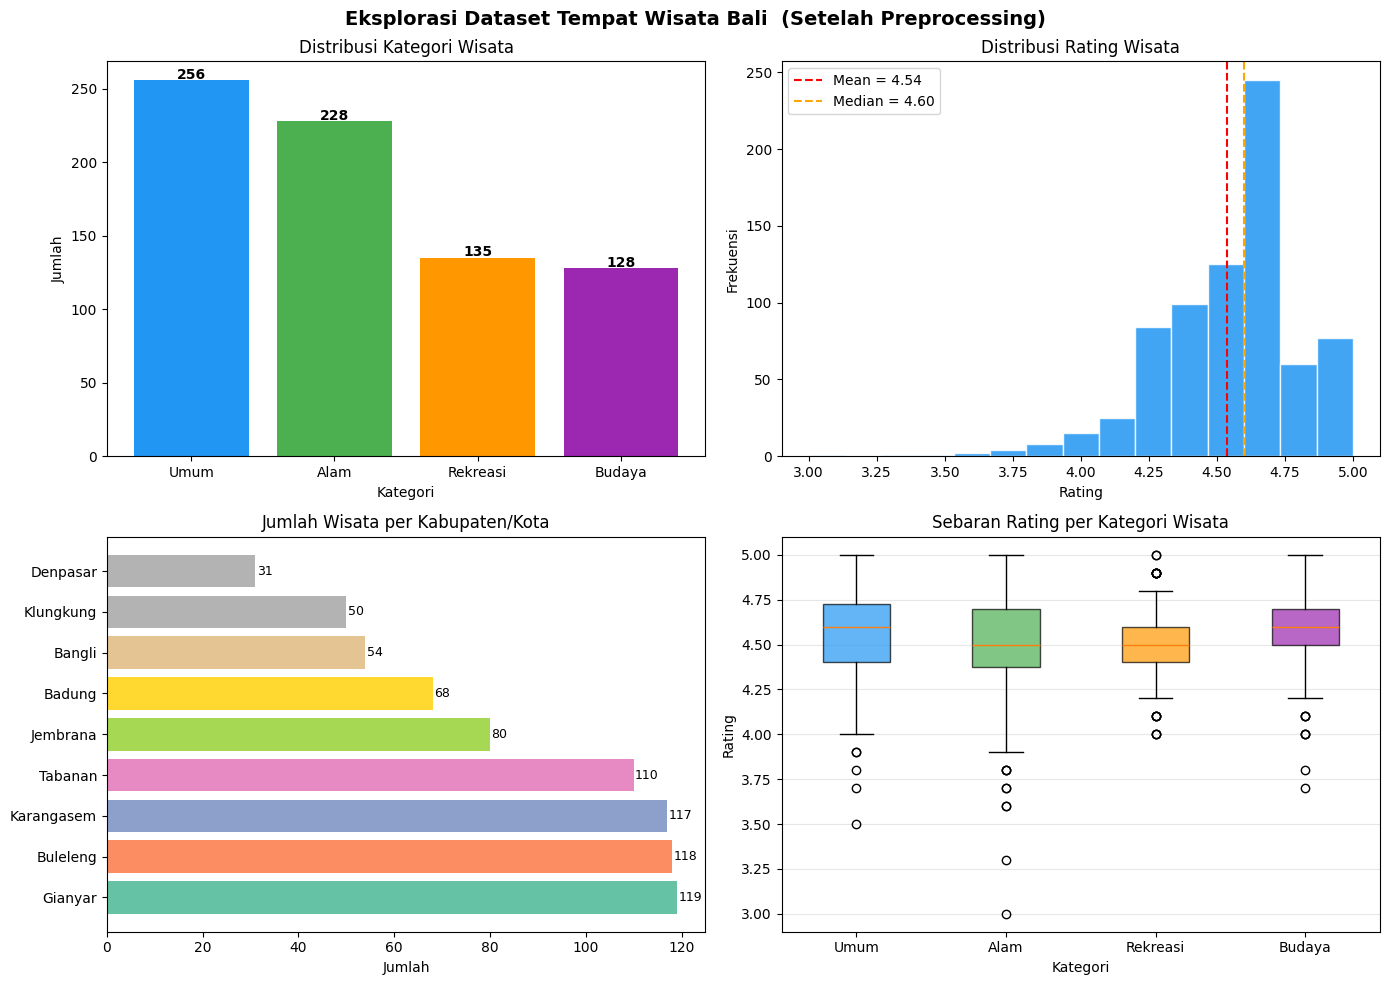

  [INFO] Grafik disimpan sebagai 'visualisasi_dataset.png'


In [ ]:
print("\n\n" + "=" * 65)
print("   BAGIAN 3 — VISUALISASI DATA (POST-PREPROCESSING)")
print("=" * 65)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Eksplorasi Dataset Tempat Wisata Bali  (Setelah Preprocessing)",
             fontsize=14, fontweight='bold')

PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# --- Plot 1: Distribusi Kategori ---
ax1 = axes[0, 0]
kat_counts = df_clean['kategori'].value_counts()
bars = ax1.bar(kat_counts.index, kat_counts.values, color=PALETTE)
ax1.set_title('Distribusi Kategori Wisata')
ax1.set_xlabel('Kategori')
ax1.set_ylabel('Jumlah')
for bar, val in zip(bars, kat_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')

# --- Plot 2: Distribusi Rating ---
ax2 = axes[0, 1]
ax2.hist(df_clean['rating'], bins=15, color='#2196F3', edgecolor='white', alpha=0.85)
ax2.axvline(df_clean['rating'].mean(),   color='red',    linestyle='--',
            label=f"Mean = {df_clean['rating'].mean():.2f}")
ax2.axvline(df_clean['rating'].median(), color='orange', linestyle='--',
            label=f"Median = {df_clean['rating'].median():.2f}")
ax2.set_title('Distribusi Rating Wisata')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Frekuensi')
ax2.legend()

# --- Plot 3: Jumlah Wisata per Kabupaten ---
ax3 = axes[1, 0]
kab_label = df_clean['kabupaten_kota'] \
    .str.replace('Kabupaten ','',regex=False) \
    .str.replace('Kota ','',regex=False)
kab_counts = kab_label.value_counts()
colors_kab = plt.cm.Set2(np.linspace(0, 1, len(kab_counts)))
ax3.barh(kab_counts.index, kab_counts.values, color=colors_kab)
ax3.set_title('Jumlah Wisata per Kabupaten/Kota')
ax3.set_xlabel('Jumlah')
for i, val in enumerate(kab_counts.values):
    ax3.text(val + 0.3, i, str(val), va='center', fontsize=9)

# --- Plot 4: Boxplot Rating per Kategori ---
ax4 = axes[1, 1]
data_by_kat = [df_clean[df_clean['kategori'] == k]['rating'].values
               for k in kat_counts.index]
bp = ax4.boxplot(data_by_kat, labels=kat_counts.index, patch_artist=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Sebaran Rating per Kategori Wisata')
ax4.set_xlabel('Kategori')
ax4.set_ylabel('Rating')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('visualisasi_dataset.png', dpi=120, bbox_inches='tight')
plt.show()
print("  [INFO] Grafik disimpan sebagai 'visualisasi_dataset.png'")

# BAGIAN 4: KNOWLEDGE BASE (RULE BASE)

In [ ]:
RULES = [
    # Layer 1 — Preferensi pengguna → Kategori wisata
    {"id":"R1",  "premis":["suka_alam"],
     "konklusi":"kategori=Alam",
     "deskripsi":"Suka alam → kategori = Alam"},
    {"id":"R2",  "premis":["suka_budaya"],
     "konklusi":"kategori=Budaya",
     "deskripsi":"Suka budaya → kategori = Budaya"},
    {"id":"R3",  "premis":["suka_rekreasi"],
     "konklusi":"kategori=Rekreasi",
     "deskripsi":"Suka rekreasi → kategori = Rekreasi"},
    {"id":"R4",  "premis":["tidak_suka_alam","tidak_suka_budaya","tidak_suka_rekreasi"],
     "konklusi":"kategori=Umum",
     "deskripsi":"Tidak ada preferensi khusus → kategori = Umum"},

    # Layer 2 — Kategori + kondisi → Filter dataset
    {"id":"R5",  "premis":["kategori=Alam","rating_tinggi"],
     "konklusi":"filter=alam_rating_tinggi",
     "deskripsi":"Alam + rating ≥ 4.5 → filter alam unggulan"},
    {"id":"R6",  "premis":["kategori=Alam","tidak_rating_tinggi"],
     "konklusi":"filter=alam_semua",
     "deskripsi":"Alam tanpa syarat rating → semua wisata alam"},
    {"id":"R7",  "premis":["kategori=Budaya","di_gianyar"],
     "konklusi":"filter=budaya_gianyar",
     "deskripsi":"Budaya + Gianyar → filter budaya Gianyar"},
    {"id":"R8",  "premis":["kategori=Budaya","di_badung"],
     "konklusi":"filter=budaya_badung",
     "deskripsi":"Budaya + Badung → filter budaya Badung"},
    {"id":"R9",  "premis":["kategori=Budaya","di_denpasar"],
     "konklusi":"filter=budaya_denpasar",
     "deskripsi":"Budaya + Denpasar → filter budaya Denpasar"},
    {"id":"R10", "premis":["kategori=Rekreasi","rating_tinggi"],
     "konklusi":"filter=rekreasi_rating_tinggi",
     "deskripsi":"Rekreasi + rating ≥ 4.5 → filter rekreasi unggulan"},
    {"id":"R11", "premis":["kategori=Rekreasi","tidak_rating_tinggi"],
     "konklusi":"filter=rekreasi_semua",
     "deskripsi":"Rekreasi tanpa syarat rating → semua wisata rekreasi"},
    {"id":"R12", "premis":["kategori=Umum","di_badung"],
     "konklusi":"filter=umum_badung",
     "deskripsi":"Umum + Badung → filter wisata umum Badung"},
    {"id":"R13", "premis":["kategori=Umum","tidak_ada_kabupaten"],
     "konklusi":"filter=umum_semua",
     "deskripsi":"Umum tanpa filter lokasi → semua wisata umum"},

    # Layer 3 — Filter → Rekomendasi akhir
    {"id":"R14", "premis":["filter=alam_rating_tinggi"],
     "konklusi":"REKOMENDASI=alam_rating_tinggi",
     "deskripsi":"→ Rekomendasikan wisata alam rating ≥ 4.5"},
    {"id":"R15", "premis":["filter=alam_semua"],
     "konklusi":"REKOMENDASI=alam_semua",
     "deskripsi":"→ Rekomendasikan semua wisata alam"},
    {"id":"R16", "premis":["filter=budaya_gianyar"],
     "konklusi":"REKOMENDASI=budaya_gianyar",
     "deskripsi":"→ Rekomendasikan wisata budaya di Gianyar"},
    {"id":"R17", "premis":["filter=budaya_badung"],
     "konklusi":"REKOMENDASI=budaya_badung",
     "deskripsi":"→ Rekomendasikan wisata budaya di Badung"},
    {"id":"R18", "premis":["filter=budaya_denpasar"],
     "konklusi":"REKOMENDASI=budaya_denpasar",
     "deskripsi":"→ Rekomendasikan wisata budaya di Denpasar"},
    {"id":"R19", "premis":["filter=rekreasi_rating_tinggi"],
     "konklusi":"REKOMENDASI=rekreasi_rating_tinggi",
     "deskripsi":"→ Rekomendasikan wisata rekreasi rating ≥ 4.5"},
    {"id":"R20", "premis":["filter=rekreasi_semua"],
     "konklusi":"REKOMENDASI=rekreasi_semua",
     "deskripsi":"→ Rekomendasikan semua wisata rekreasi"},
    {"id":"R21", "premis":["filter=umum_badung"],
     "konklusi":"REKOMENDASI=umum_badung",
     "deskripsi":"→ Rekomendasikan wisata umum di Badung"},
    {"id":"R22", "premis":["filter=umum_semua"],
     "konklusi":"REKOMENDASI=umum_semua",
     "deskripsi":"→ Rekomendasikan semua wisata umum"},
]

# Pemetaan kode rekomendasi → parameter query dataset
FILTER_MAP = {
    "REKOMENDASI=alam_rating_tinggi"    : dict(kategori="Alam",     rating_min=4.5),
    "REKOMENDASI=alam_semua"             : dict(kategori="Alam"),
    "REKOMENDASI=budaya_gianyar"         : dict(kategori="Budaya",   kabupaten="Gianyar"),
    "REKOMENDASI=budaya_badung"          : dict(kategori="Budaya",   kabupaten="Badung"),
    "REKOMENDASI=budaya_denpasar"        : dict(kategori="Budaya",   kabupaten="Denpasar"),
    "REKOMENDASI=rekreasi_rating_tinggi" : dict(kategori="Rekreasi", rating_min=4.5),
    "REKOMENDASI=rekreasi_semua"         : dict(kategori="Rekreasi"),
    "REKOMENDASI=umum_badung"            : dict(kategori="Umum",     kabupaten="Badung"),
    "REKOMENDASI=umum_semua"             : dict(kategori="Umum"),
}

def get_wisata(df, kategori=None, kabupaten=None, rating_min=None, limit=5):
    res = df.copy()
    if kategori   : res = res[res['kategori'] == kategori]
    if kabupaten  : res = res[res['kabupaten_kota'].str.contains(kabupaten, case=False, na=False)]
    if rating_min : res = res[res['rating'] >= rating_min]
    return res.sort_values('rating', ascending=False)[
        ['nama','kategori','kabupaten_kota','rating']].head(limit)

def get_rekomendasi(key, df):
    return get_wisata(df, **FILTER_MAP.get(key, {}), limit=5)

# BAGIAN 5: FORWARD CHAINING

In [ ]:
def forward_chaining(fakta_awal, rules, df, verbose=True):
    """
    Algoritma Forward Chaining (Penalaran Maju / Data-Driven).

    Alur:
    1. Inisialisasi basis fakta dengan fakta awal pengguna.
    2. Telusuri semua rule; jika semua premis rule ada di basis fakta,
       eksekusi rule → tambahkan konklusi ke basis fakta.
    3. Ulangi sampai tidak ada rule baru yang bisa dieksekusi.
    4. Cari konklusi REKOMENDASI= sebagai output akhir.
    """
    fakta           = set(fakta_awal)
    fired           = set()
    log             = []
    rekomendasi_key = None

    if verbose:
        print("\n" + "=" * 65)
        print("   FORWARD CHAINING — PENALARAN MAJU (DATA-DRIVEN)")
        print("=" * 65)
        print(f"\n  Fakta Awal : {sorted(fakta)}")
        print(f"  Jumlah Rule: {len(rules)}")
        print("\n" + "─" * 65)

    iterasi = 0
    changed = True

    while changed:
        changed = False
        for rule in rules:
            if rule["id"] in fired:
                continue
            if all(p in fakta for p in rule["premis"]):
                iterasi += 1
                konklusi = rule["konklusi"]
                fakta.add(konklusi)
                fired.add(rule["id"])
                changed = True
                log.append({"iterasi": iterasi, "rule_id": rule["id"],
                             "premis": rule["premis"], "konklusi": konklusi,
                             "deskripsi": rule["deskripsi"]})
                if verbose:
                    print(f"\n  [Iterasi {iterasi}]")
                    print(f"    Rule     : {rule['id']}")
                    print(f"    Premis   : {rule['premis']}")
                    print(f"    Konklusi : {konklusi} ✓")
                    print(f"    Ket.     : {rule['deskripsi']}")
                if konklusi.startswith("REKOMENDASI="):
                    rekomendasi_key = konklusi

    if verbose:
        print("\n" + "─" * 65)
        print(f"\n  Proses selesai. Total {iterasi} rule dieksekusi.")
        print(f"  Fakta Akhir: {sorted(fakta)}")

    hasil = None
    if rekomendasi_key:
        hasil = get_rekomendasi(rekomendasi_key, df)
        if verbose:
            print(f"\n  {'─'*55}")
            print(f"  REKOMENDASI WISATA BALI (kode: {rekomendasi_key})")
            print(f"  {'─'*55}")
            print(tabulate(hasil, headers='keys', tablefmt='grid', showindex=False))
    elif verbose:
        print("\n  [!] Tidak ditemukan rekomendasi yang cocok.")

    return {"fakta_akhir": fakta, "rule_dieksekusi": list(fired),
            "log": log, "rekomendasi_key": rekomendasi_key, "hasil": hasil}


# BAGIAN 6: BACKWARD CHAINING

In [ ]:
def backward_chaining(goal, rules, fakta_awal, df, verbose=True):
    """
    Algoritma Backward Chaining (Penalaran Mundur / Goal-Driven).

    Alur:
    1. Mulai dari GOAL yang ingin dibuktikan.
    2. Cari rule yang konklusinya = GOAL.
    3. Untuk setiap premis rule:
       - Jika ada di basis fakta → terpenuhi ✓
       - Jika tidak → jadikan SUBGOAL, rekursi (kembali ke langkah 2)
       - Jika tidak ada rule untuk subgoal → GAGAL ✗
    4. Jika semua premis terpenuhi → GOAL TERBUKTI ✓
    """
    fakta           = set(fakta_awal)
    log             = []
    iterasi_counter = [0]

    if verbose:
        print("\n" + "=" * 65)
        print("   BACKWARD CHAINING — PENALARAN MUNDUR (GOAL-DRIVEN)")
        print("=" * 65)
        print(f"\n  GOAL      : {goal}")
        print(f"  Fakta Awal: {sorted(fakta)}")
        print("\n" + "─" * 65)

    def prove(current_goal, depth=0):
        indent = "    " * depth
        iterasi_counter[0] += 1
        it = iterasi_counter[0]

        if verbose:
            print(f"\n{indent}[Iterasi {it}] Buktikan: '{current_goal}'")

        if current_goal in fakta:
            if verbose:
                print(f"{indent}  → Sudah ada di basis fakta ✓")
            log.append({"iterasi":it,"goal":current_goal,
                        "status":"TERBUKTI (fakta)","depth":depth})
            return True

        matching = [r for r in rules if r["konklusi"] == current_goal]
        if not matching:
            if verbose:
                print(f"{indent}  → Tidak ada rule untuk goal ini ✗")
            log.append({"iterasi":it,"goal":current_goal,
                        "status":"GAGAL (tidak ada rule)","depth":depth})
            return False

        for rule in matching:
            if verbose:
                print(f"{indent}  Coba {rule['id']}: {rule['deskripsi']}")
                print(f"{indent}  Premis dibutuhkan: {rule['premis']}")

            all_ok = True
            for premis in rule["premis"]:
                if premis not in fakta:
                    if verbose:
                        print(f"{indent}  ↳ '{premis}' belum ada → jadikan SUBGOAL")
                    if not prove(premis, depth+1):
                        all_ok = False
                        if verbose:
                            print(f"{indent}  ✗ SUBGOAL '{premis}' gagal")
                        break
                    else:
                        fakta.add(premis)

            if all_ok:
                fakta.add(current_goal)
                if verbose:
                    print(f"{indent}  ✓ Semua premis terpenuhi! '{current_goal}' TERBUKTI")
                log.append({"iterasi":it,"goal":current_goal,
                            "status":f"TERBUKTI (rule {rule['id']})",
                            "rule_used":rule["id"],"depth":depth})
                return True

        log.append({"iterasi":it,"goal":current_goal,
                    "status":"GAGAL (semua rule gagal)","depth":depth})
        if verbose:
            print(f"{indent}  ✗ '{current_goal}' tidak dapat dibuktikan")
        return False

    terbukti = prove(goal)

    if verbose:
        print("\n" + "─" * 65)
        print(f"\n  Status GOAL '{goal}': {'✓ TERBUKTI' if terbukti else '✗ TIDAK TERBUKTI'}")
        print(f"  Fakta Akhir: {sorted(fakta)}")

    hasil = None
    if terbukti and goal.startswith("REKOMENDASI="):
        hasil = get_rekomendasi(goal, df)
        if verbose:
            print(f"\n  {'─'*55}")
            print(f"  REKOMENDASI WISATA BALI (kode: {goal})")
            print(f"  {'─'*55}")
            print(tabulate(hasil, headers='keys', tablefmt='grid', showindex=False))

    return {"goal":goal,"terbukti":terbukti,"fakta_akhir":fakta,
            "log":log,"hasil":hasil}

# BAGIAN 7 & 8: DEMONSTRASI

In [ ]:
print("\n\n" + "=" * 65)
print("   BAGIAN 7 — DEMONSTRASI FORWARD CHAINING")
print("=" * 65)

print("\n▶▶▶ KASUS 1: Wisatawan suka alam, ingin rating tinggi")
forward_chaining({"suka_alam","rating_tinggi"}, RULES, df_clean, verbose=True)

print("\n\n▶▶▶ KASUS 2: Wisatawan suka budaya, tujuan ke Gianyar")
forward_chaining({"suka_budaya","di_gianyar"}, RULES, df_clean, verbose=True)

print("\n\n" + "=" * 65)
print("   BAGIAN 8 — DEMONSTRASI BACKWARD CHAINING")
print("=" * 65)

print("\n▶▶▶ KASUS 3: Buktikan REKOMENDASI wisata alam rating tinggi")
backward_chaining("REKOMENDASI=alam_rating_tinggi",
                  RULES, {"suka_alam","rating_tinggi"}, df_clean, verbose=True)

print("\n\n▶▶▶ KASUS 4: Buktikan REKOMENDASI wisata budaya di Badung")
backward_chaining("REKOMENDASI=budaya_badung",
                  RULES, {"suka_budaya","di_badung"}, df_clean, verbose=True)



   BAGIAN 7 — DEMONSTRASI FORWARD CHAINING

▶▶▶ KASUS 1: Wisatawan suka alam, ingin rating tinggi

   FORWARD CHAINING — PENALARAN MAJU (DATA-DRIVEN)

  Fakta Awal : ['rating_tinggi', 'suka_alam']
  Jumlah Rule: 22

─────────────────────────────────────────────────────────────────

  [Iterasi 1]
    Rule     : R1
    Premis   : ['suka_alam']
    Konklusi : kategori=Alam ✓
    Ket.     : Suka alam → kategori = Alam

  [Iterasi 2]
    Rule     : R5
    Premis   : ['kategori=Alam', 'rating_tinggi']
    Konklusi : filter=alam_rating_tinggi ✓
    Ket.     : Alam + rating ≥ 4.5 → filter alam unggulan

  [Iterasi 3]
    Rule     : R14
    Premis   : ['filter=alam_rating_tinggi']
    Konklusi : REKOMENDASI=alam_rating_tinggi ✓
    Ket.     : → Rekomendasikan wisata alam rating ≥ 4.5

─────────────────────────────────────────────────────────────────

  Proses selesai. Total 3 rule dieksekusi.
  Fakta Akhir: ['REKOMENDASI=alam_rating_tinggi', 'filter=alam_rating_tinggi', 'kategori=Alam', 'rati

{'goal': 'REKOMENDASI=budaya_badung',
 'terbukti': True,
 'fakta_akhir': {'REKOMENDASI=budaya_badung',
  'di_badung',
  'filter=budaya_badung',
  'kategori=Budaya',
  'suka_budaya'},
 'log': [{'iterasi': 3,
   'goal': 'kategori=Budaya',
   'status': 'TERBUKTI (rule R2)',
   'rule_used': 'R2',
   'depth': 2},
  {'iterasi': 2,
   'goal': 'filter=budaya_badung',
   'status': 'TERBUKTI (rule R8)',
   'rule_used': 'R8',
   'depth': 1},
  {'iterasi': 1,
   'goal': 'REKOMENDASI=budaya_badung',
   'status': 'TERBUKTI (rule R17)',
   'rule_used': 'R17',
   'depth': 0}],
 'hasil':                            nama kategori    kabupaten_kota  rating
 47            Pura Puncak Mangu   Budaya  Kabupaten Badung     4.8
 60                Museum Yadnya   Budaya  Kabupaten Badung     4.8
 50   Pura Gede Luhur Batu Ngaus   Budaya  Kabupaten Badung     4.7
 18             Pura Geger Beach   Budaya  Kabupaten Badung     4.7
 8   Gunung Payung Cultural Park   Budaya  Kabupaten Badung     4.6}

# BAGIAN 9: SISTEM INTERAKTIF

In [ ]:
def sistem_interaktif(df):
    """Sistem rekomendasi wisata Bali interaktif berbasis inferensi."""
    print("\n" + "=" * 65)
    print("   SISTEM REKOMENDASI WISATA BALI — INTERAKTIF")
    print("=" * 65)
    print("\nJawab pertanyaan berikut (y = ya, n = tidak):\n")
    fakta = set()

    suka_alam     = input("  Apakah Anda suka wisata alam?          (y/n): ").lower()=='y'
    suka_budaya   = input("  Apakah Anda suka wisata budaya?        (y/n): ").lower()=='y'
    suka_rekreasi = input("  Apakah Anda suka wisata rekreasi?      (y/n): ").lower()=='y'
    rating_tinggi = input("  Ingin tempat dengan rating \u2265 4.5 saja? (y/n): ").lower()=='y'

    print("\n  Pilih kabupaten/kota tujuan:")
    print("  1. Badung   2. Gianyar   3. Denpasar   4. Semua")
    kab = input("  Pilihan (1/2/3/4): ").strip()

    if suka_alam     : fakta.add("suka_alam")
    else             : fakta.add("tidak_suka_alam")
    if suka_budaya   : fakta.add("suka_budaya")
    else             : fakta.add("tidak_suka_budaya")
    if suka_rekreasi : fakta.add("suka_rekreasi")
    else             : fakta.add("tidak_suka_rekreasi")
    if rating_tinggi : fakta.add("rating_tinggi")
    else             : fakta.add("tidak_rating_tinggi")

    kab_map = {'1':'di_badung','2':'di_gianyar',
               '3':'di_denpasar','4':'tidak_ada_kabupaten'}
    fakta.add(kab_map.get(kab, 'tidak_ada_kabupaten'))

    print("\n  Pilih metode inferensi:")
    print("  1. Forward Chaining   2. Backward Chaining")
    metode = input("  Pilihan (1/2): ").strip()

    if metode == '1':
        forward_chaining(fakta, RULES, df, verbose=True)
    elif metode == '2':
        # Tentukan goal otomatis dari fakta
        if   "suka_alam" in fakta and "rating_tinggi" in fakta : goal="REKOMENDASI=alam_rating_tinggi"
        elif "suka_alam" in fakta                              : goal="REKOMENDASI=alam_semua"
        elif "suka_budaya" in fakta and "di_gianyar" in fakta  : goal="REKOMENDASI=budaya_gianyar"
        elif "suka_budaya" in fakta and "di_badung" in fakta   : goal="REKOMENDASI=budaya_badung"
        elif "suka_budaya" in fakta and "di_denpasar" in fakta : goal="REKOMENDASI=budaya_denpasar"
        elif "suka_rekreasi" in fakta and "rating_tinggi" in fakta: goal="REKOMENDASI=rekreasi_rating_tinggi"
        elif "suka_rekreasi" in fakta                          : goal="REKOMENDASI=rekreasi_semua"
        elif "di_badung" in fakta                              : goal="REKOMENDASI=umum_badung"
        else                                                   : goal="REKOMENDASI=umum_semua"
        backward_chaining(goal, RULES, fakta, df, verbose=True)

sistem_interaktif(df_clean)


   SISTEM REKOMENDASI WISATA BALI — INTERAKTIF

Jawab pertanyaan berikut (y = ya, n = tidak):

  Apakah Anda suka wisata alam?          (y/n): y
  Apakah Anda suka wisata budaya?        (y/n): n
  Apakah Anda suka wisata rekreasi?      (y/n): y
  Ingin tempat dengan rating ≥ 4.5 saja? (y/n): y

  Pilih kabupaten/kota tujuan:
  1. Badung   2. Gianyar   3. Denpasar   4. Semua
  Pilihan (1/2/3/4): 2

  Pilih metode inferensi:
  1. Forward Chaining   2. Backward Chaining
  Pilihan (1/2): 1

   FORWARD CHAINING — PENALARAN MAJU (DATA-DRIVEN)

  Fakta Awal : ['di_gianyar', 'rating_tinggi', 'suka_alam', 'suka_rekreasi', 'tidak_suka_budaya']
  Jumlah Rule: 22

─────────────────────────────────────────────────────────────────

  [Iterasi 1]
    Rule     : R1
    Premis   : ['suka_alam']
    Konklusi : kategori=Alam ✓
    Ket.     : Suka alam → kategori = Alam

  [Iterasi 2]
    Rule     : R3
    Premis   : ['suka_rekreasi']
    Konklusi : kategori=Rekreasi ✓
    Ket.     : Suka rekreasi → kate

# BAGIAN 10: PERBANDINGAN METODE

In [ ]:
print("\n\n" + "=" * 65)
print("   BAGIAN 10 — PERBANDINGAN FORWARD vs BACKWARD CHAINING")
print("=" * 65)

perbandingan = [
    ["Pendekatan",      "Data-driven (Bawah → Atas)",     "Goal-driven (Atas → Bawah)"],
    ["Dimulai dari",    "Fakta yang diketahui",            "Tujuan / hipotesis"],
    ["Cara kerja",      "Fakta → Rule → Konklusi baru",   "Goal → Sub-goal → Fakta"],
    ["Jenis pencarian", "Breadth-first search",            "Depth-first search"],
    ["Efisiensi",       "Baik jika banyak fakta awal",     "Baik jika goal sudah jelas"],
    ["Cocok untuk",     "Monitoring, perencanaan",         "Diagnosis, debugging"],
    ["Contoh kasus ini","Preferensi → rekomendasi",        "Target wisata → validasi fakta"],
]
print(tabulate(perbandingan,
               headers=["Atribut","Forward Chaining","Backward Chaining"],
               tablefmt='grid'))

print(f"\n[✓] Program selesai.")
print(f"    Dataset        : {DATASET_PATH}")
print(f"    Data bersih    : {len(df_clean)} tempat wisata")
print(f"    Jumlah rule    : {len(RULES)} rule")
print(f"    Data dihapus   : {prep_report['n_dihapus']} baris")



   BAGIAN 10 — PERBANDINGAN FORWARD vs BACKWARD CHAINING
+------------------+------------------------------+--------------------------------+
| Atribut          | Forward Chaining             | Backward Chaining              |
+==================+==============================+================================+
| Pendekatan       | Data-driven (Bawah → Atas)   | Goal-driven (Atas → Bawah)     |
+------------------+------------------------------+--------------------------------+
| Dimulai dari     | Fakta yang diketahui         | Tujuan / hipotesis             |
+------------------+------------------------------+--------------------------------+
| Cara kerja       | Fakta → Rule → Konklusi baru | Goal → Sub-goal → Fakta        |
+------------------+------------------------------+--------------------------------+
| Jenis pencarian  | Breadth-first search         | Depth-first search             |
+------------------+------------------------------+--------------------------------+
| Efis